# CNN FUNDAMENTALS
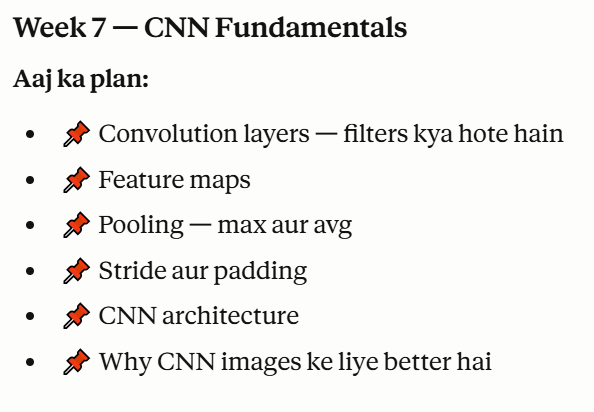

# CNN kya hota hai
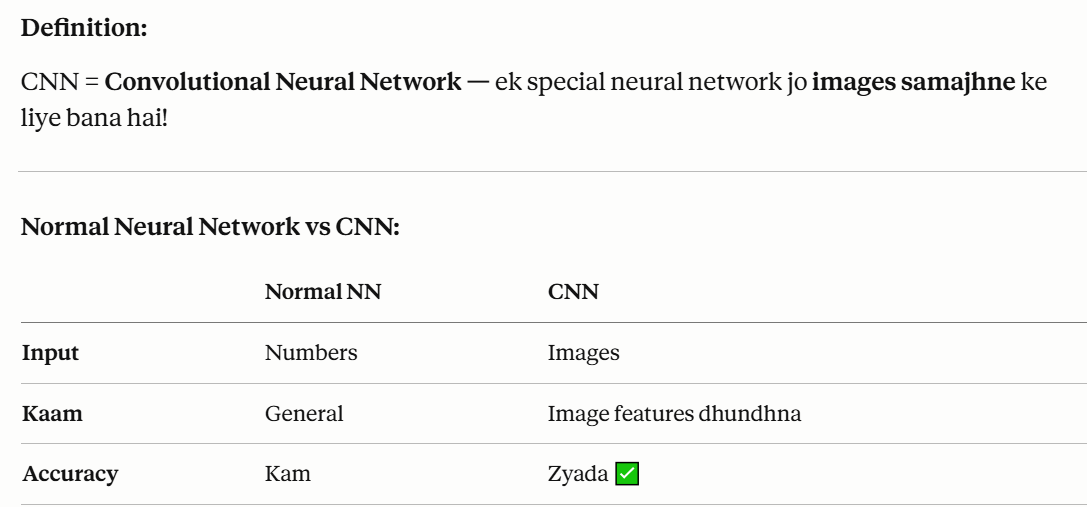

# Convolution Layer aur Filters kya hote hain?
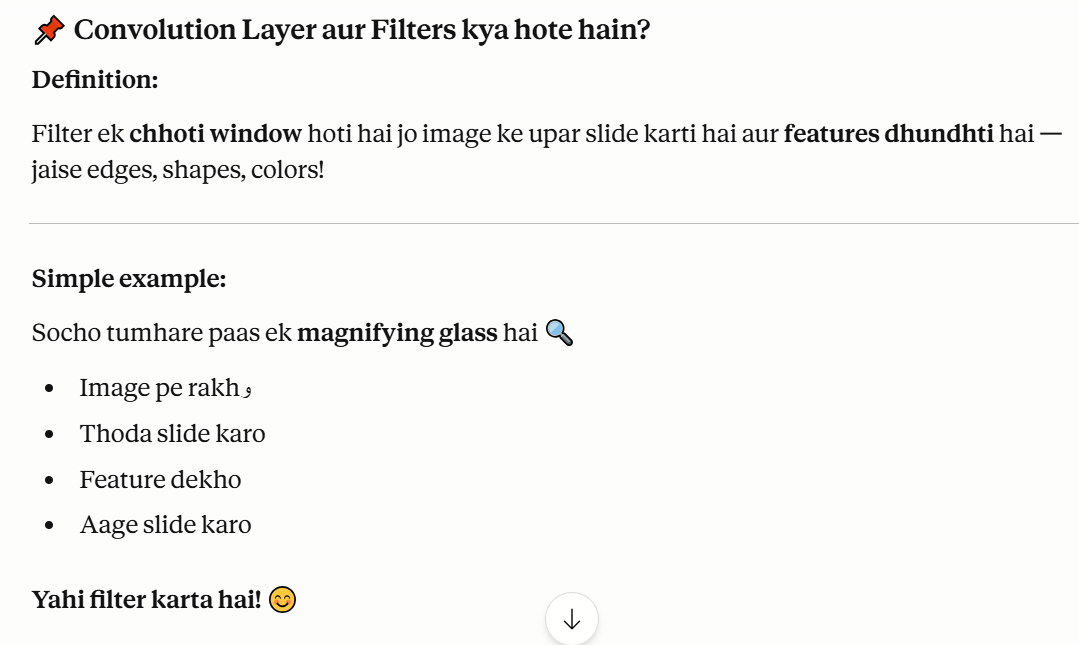
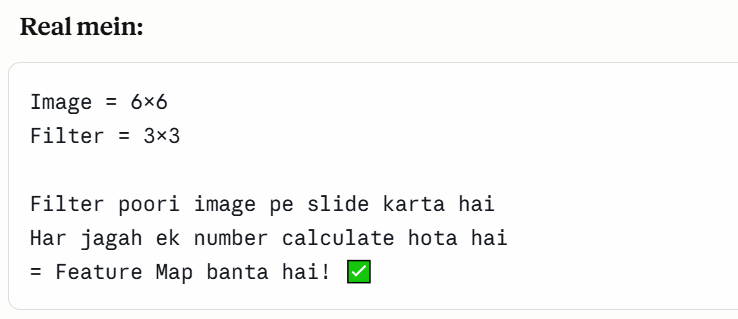
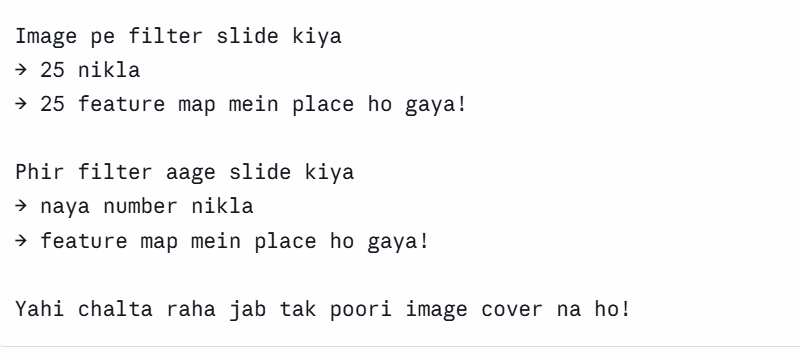

# Feature Map kya hota hai?
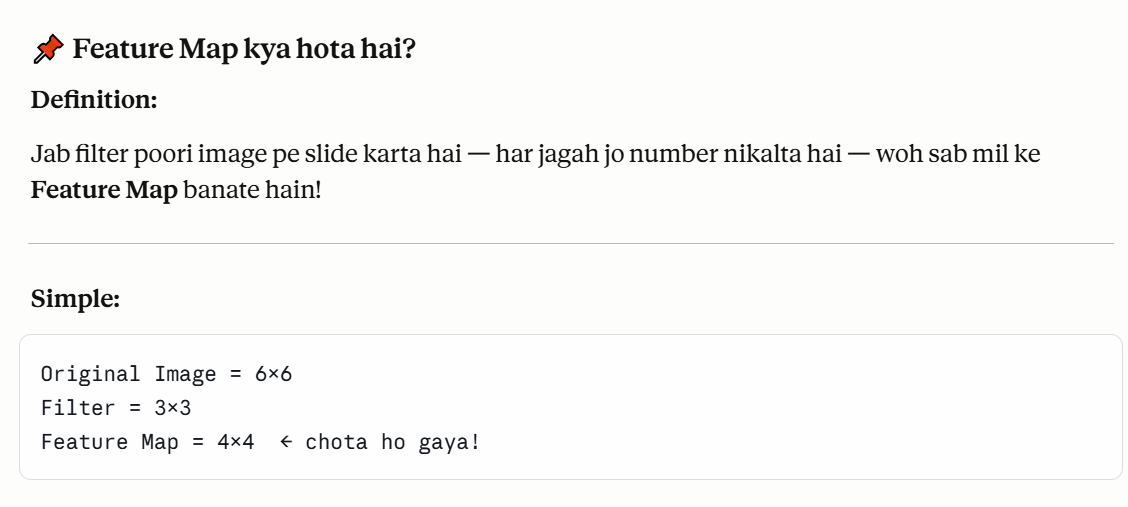

#  Pooling kya hota hai
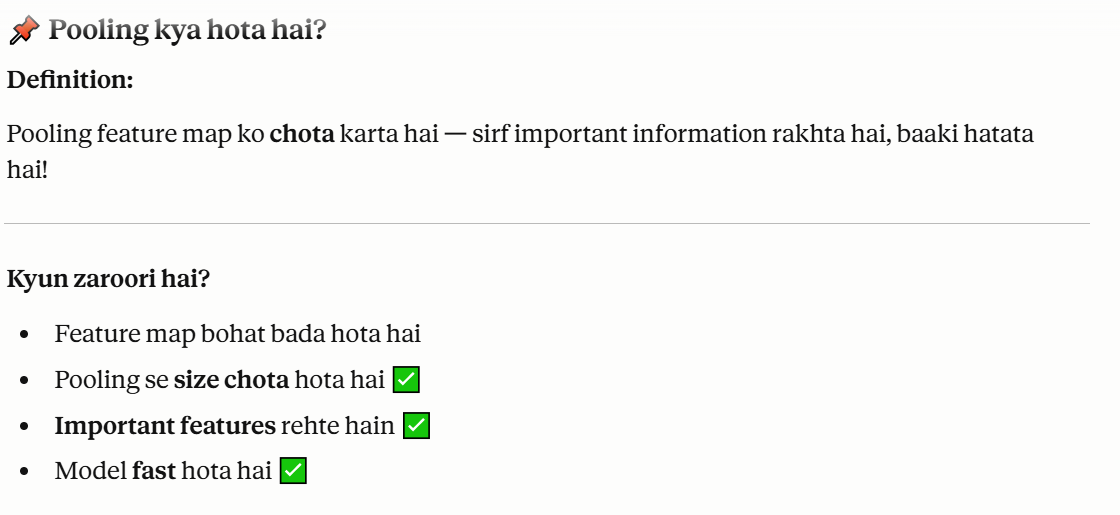
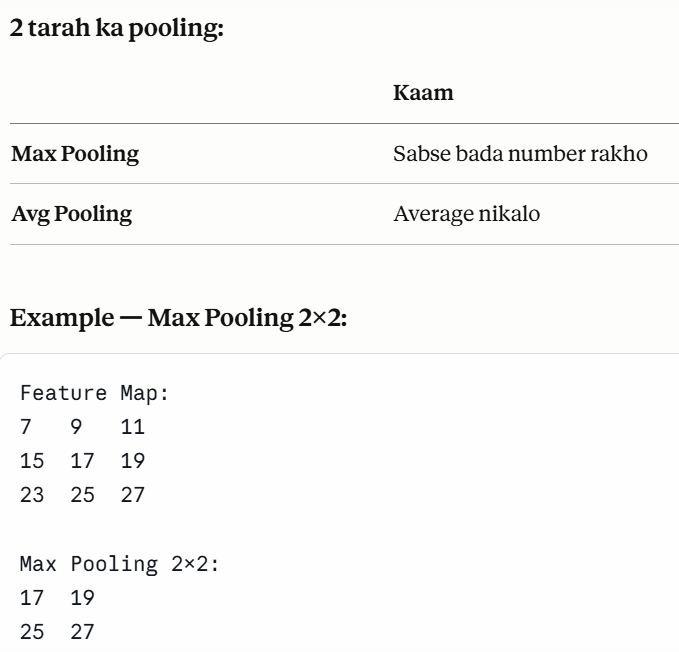

# Stride aur Padding kya hota hai?
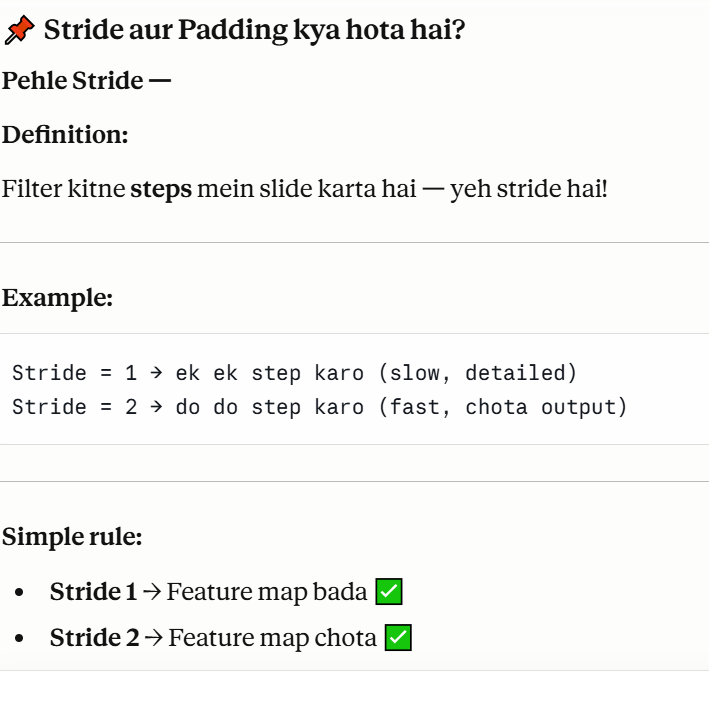

# Padding
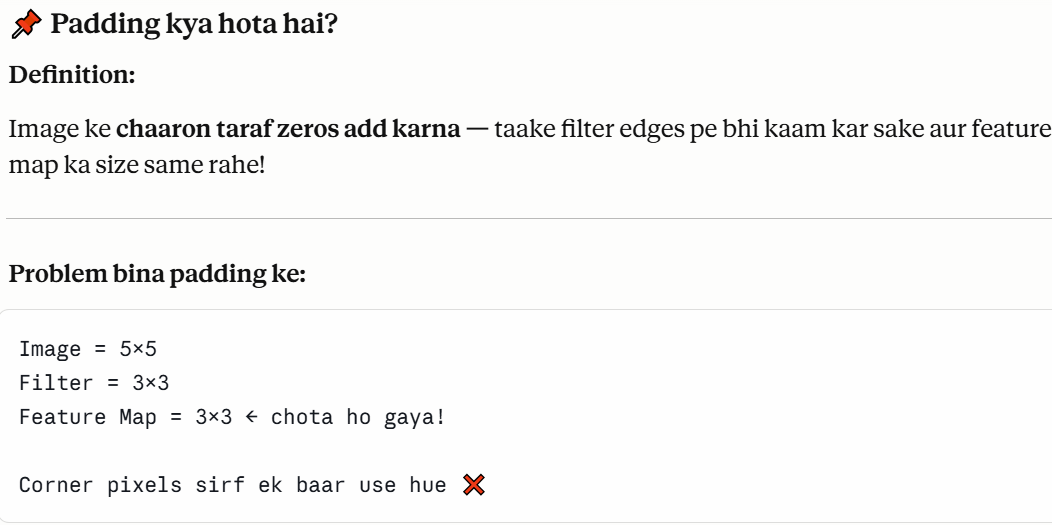
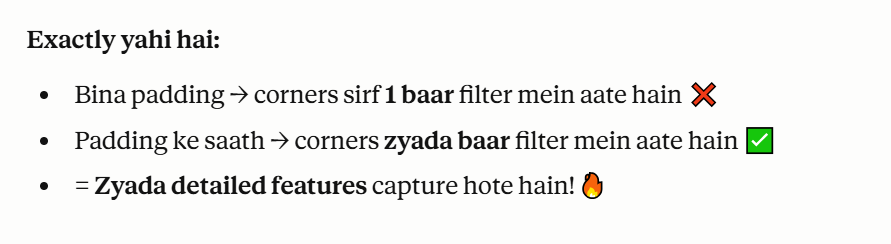

#  CNN Architecture kya hoti hai?
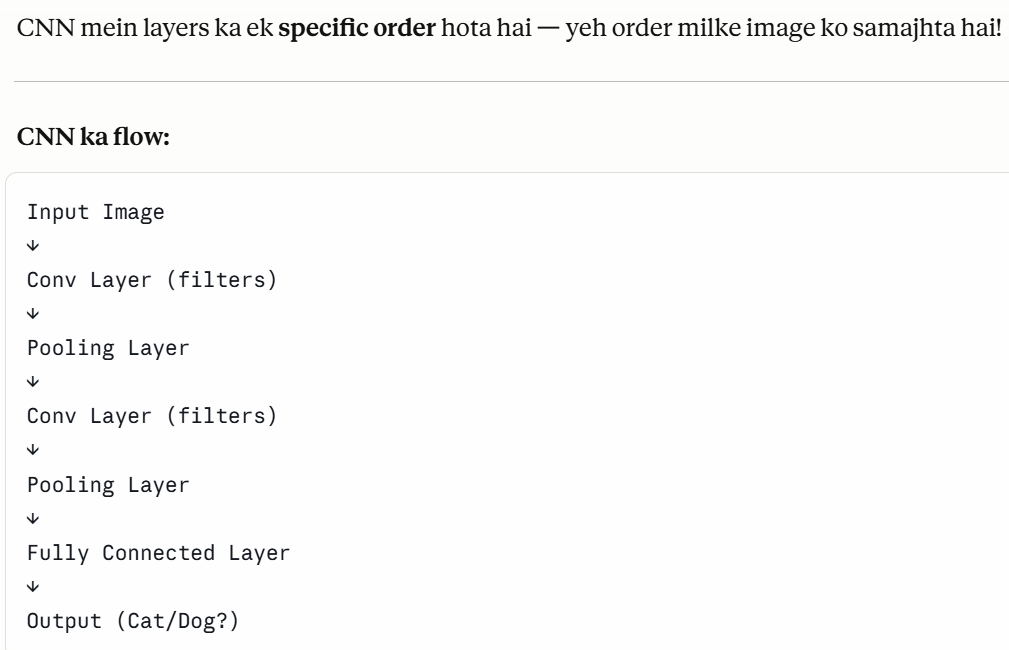
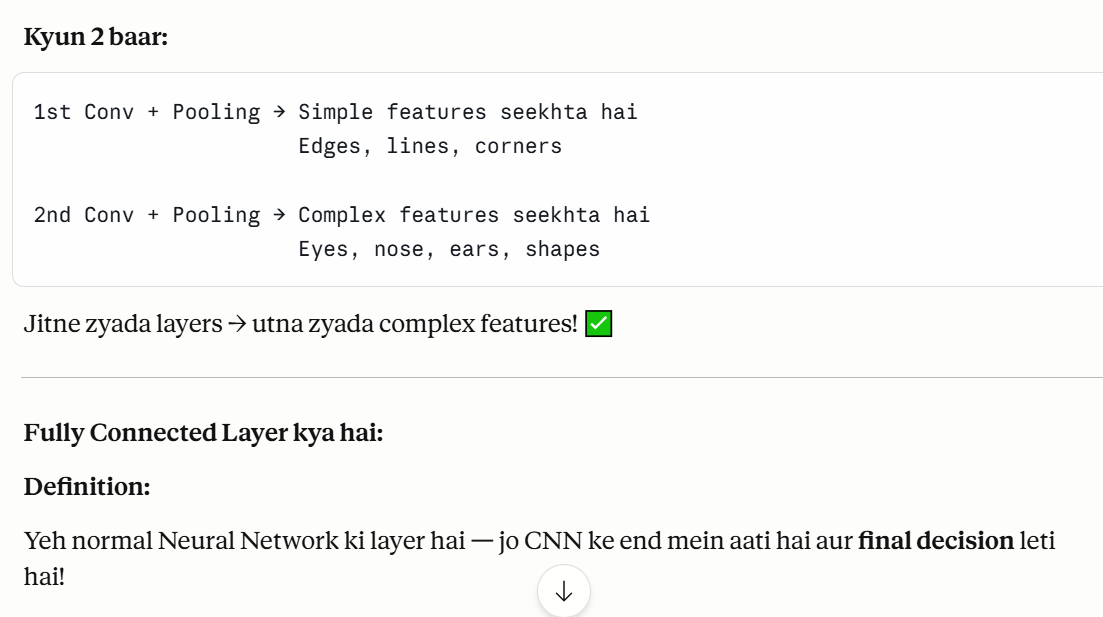
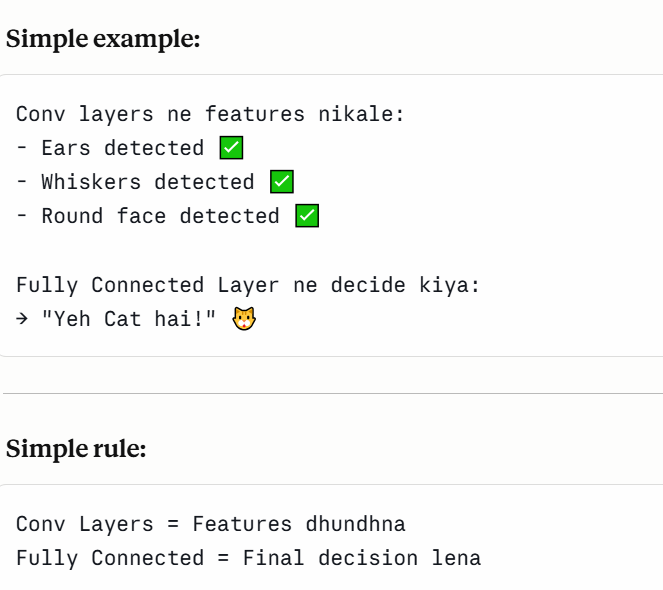
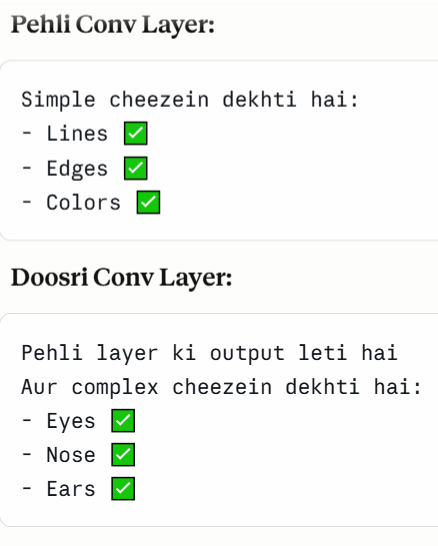
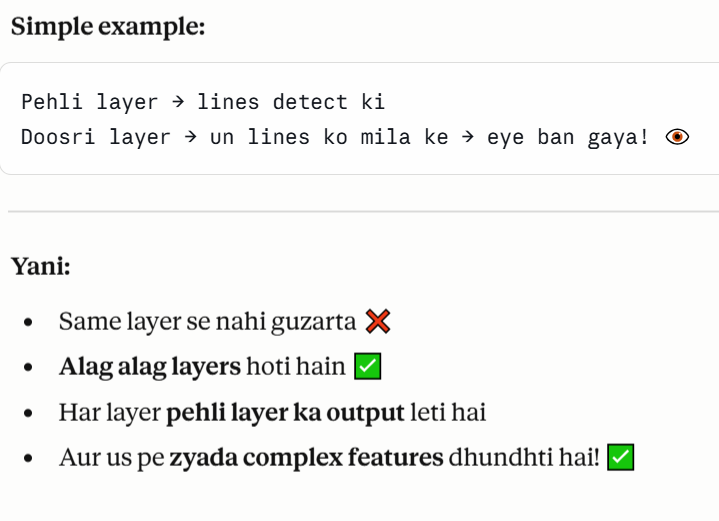

# 📌 Why CNN images ke liye better hai
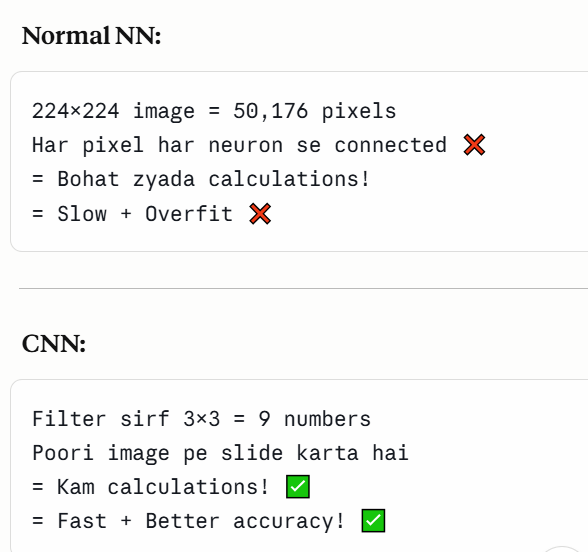
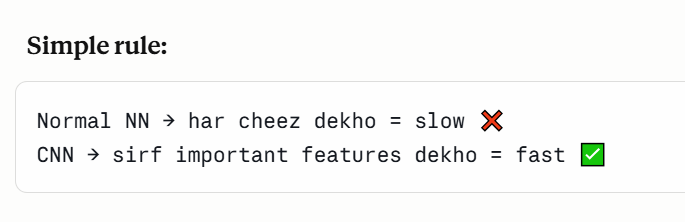

# MNIST kya hai
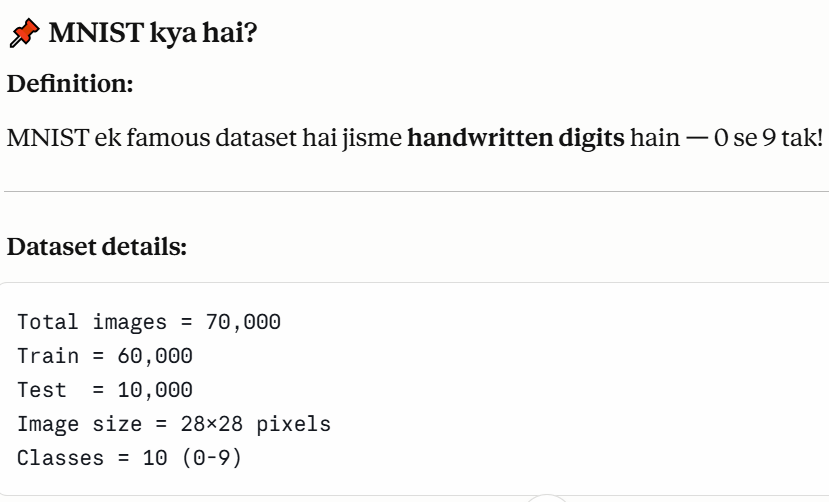

In [27]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import torch
import torch.nn as nn
import torchvision
# PyTorch ki image library hai
# Famous datasets provide karta hai
# jaise MNIST, CIFAR-10, ImageNet
# Bina torchvision ke MNIST download nahi hoti!
import torchvision.transforms as transforms
# Images ko model ke liye taiyar karta hai
# jaise:
# - Image ko Tensor banao
# - Normalize karo
# - Resize karo
# - Flip karo (data augmentation)
import matplotlib.pyplot as plt
# Graphs banane ki library
# plt = shortcut naam diya hai
# jaise:
# plt.plot()   → line graph
# plt.imshow() → image dikhao
# plt.show()   → graph display karo

In [29]:
# Transform — image ko tensor banao aur normalize karo
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Matlab = multiple transforms ek saath lagao
# Ek ke baad ek automatically chalta hai!

# Jaise:
# Step 1 → ToTensor
# Step 2 → Normalize
# Dono ek saath = Compose!
# Train data


train_data = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True,  #agr download nhi hai to kro otherwise skip kro
    transform=transform
)

# Test data
test_data = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform #is pr transform.compose operationappy kro
)

print(f"Train: {len(train_data)}")
print(f"Test:  {len(test_data)}")

Train: 60000
Test:  10000


# apna dataset ho agr
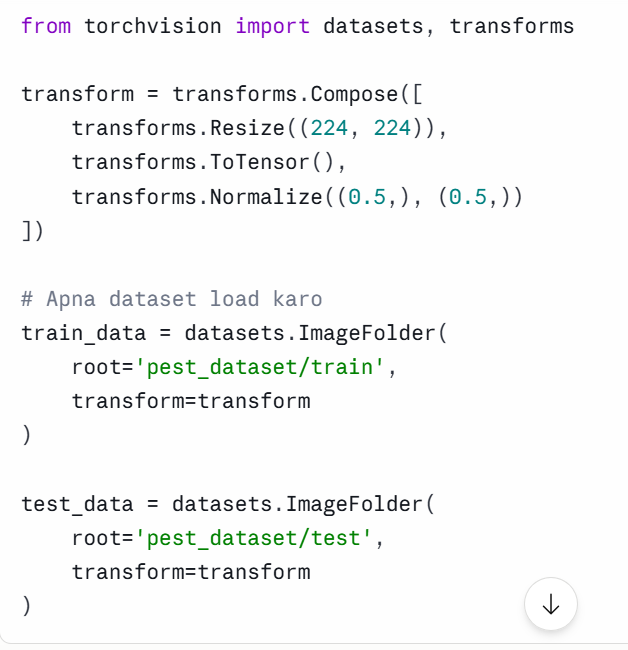
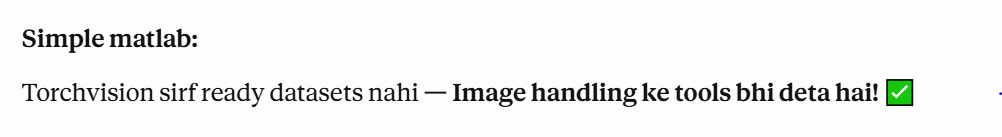
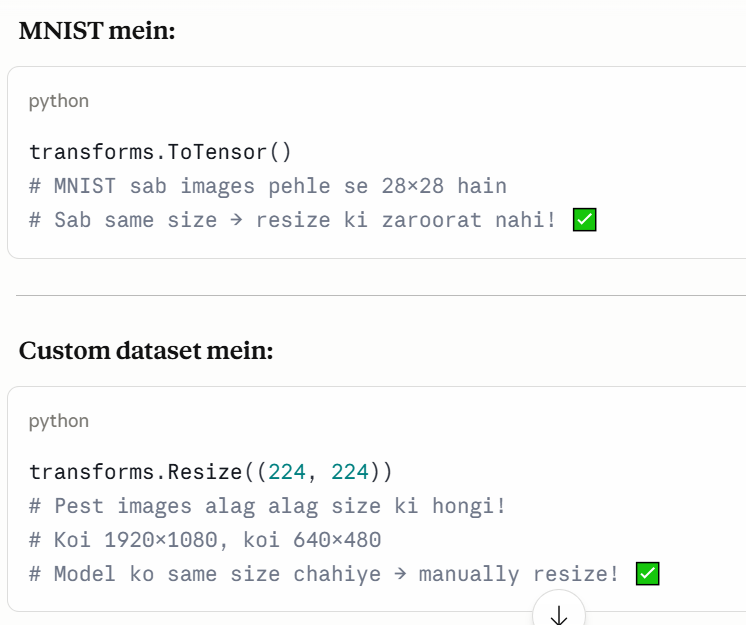
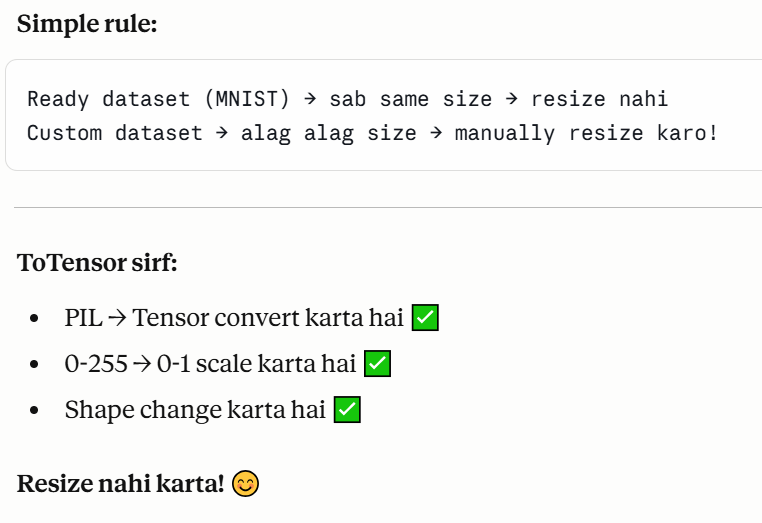

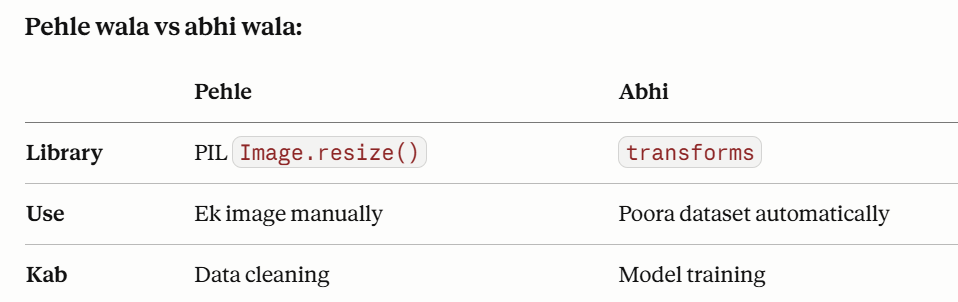
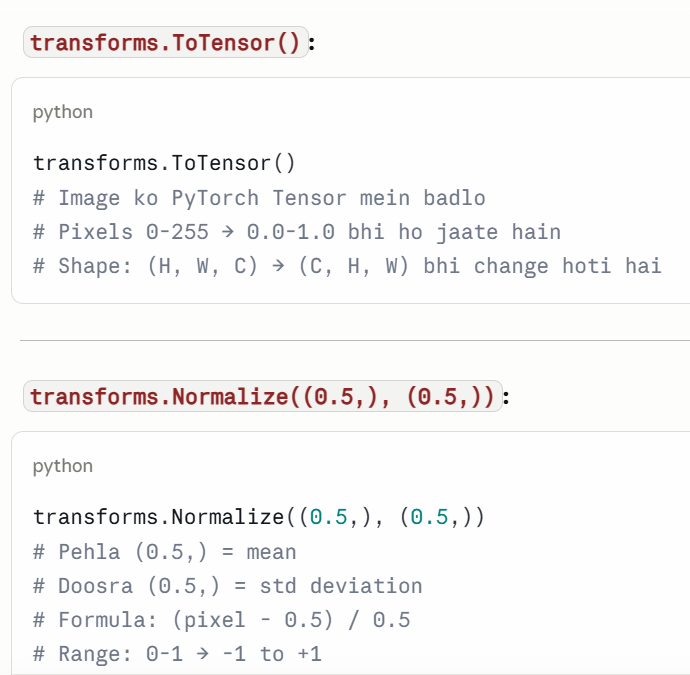
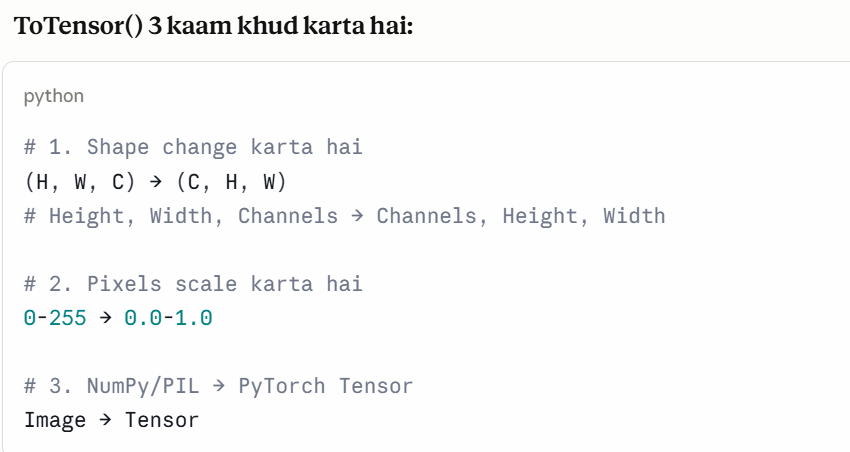
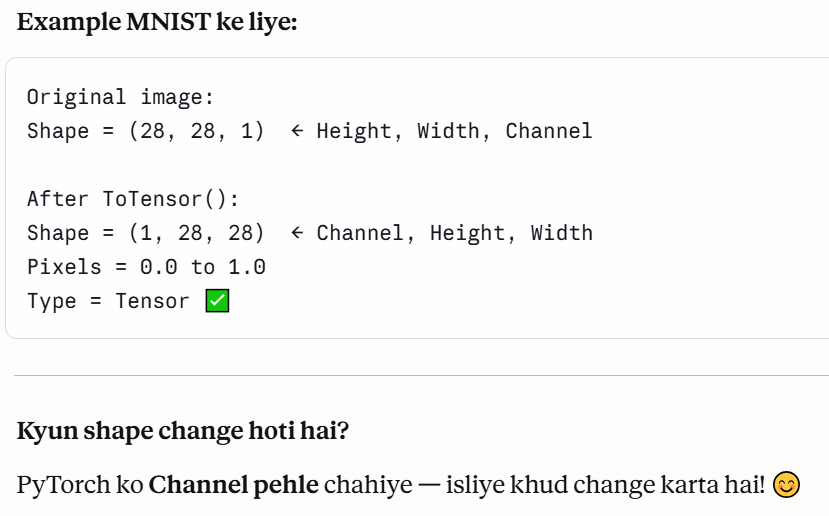

In [30]:
# Dataset ko model ke liye taiyar karta hai
# Batches mein todta hai
# Shuffle karta hai

train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size=64, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=64, 
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 938
Test batches:  157


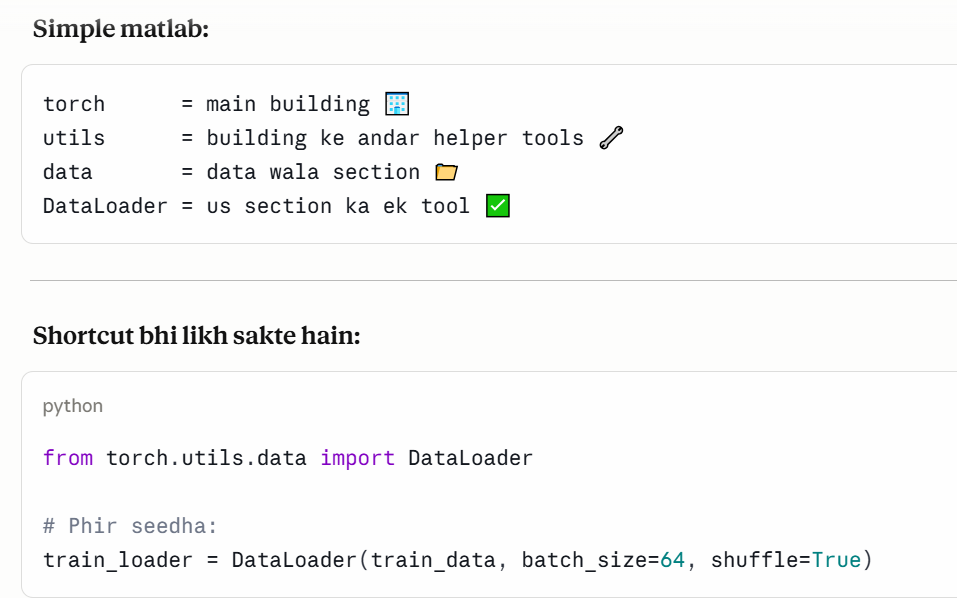

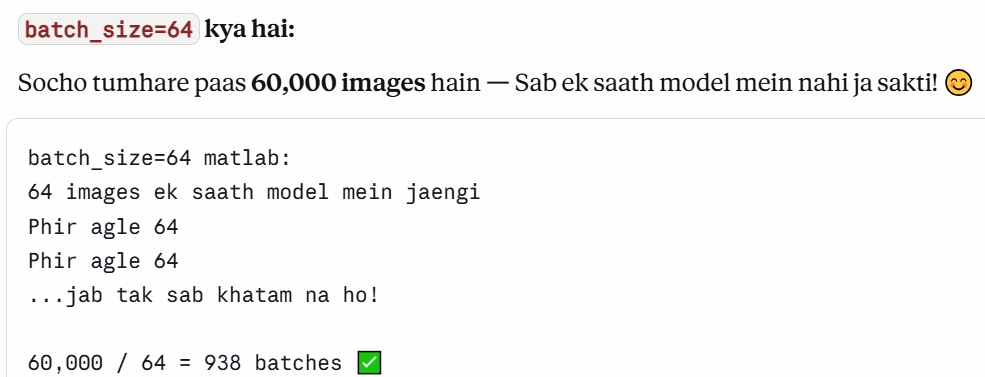
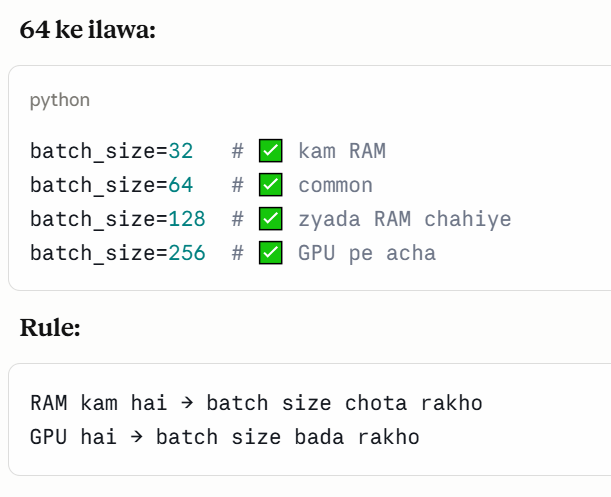

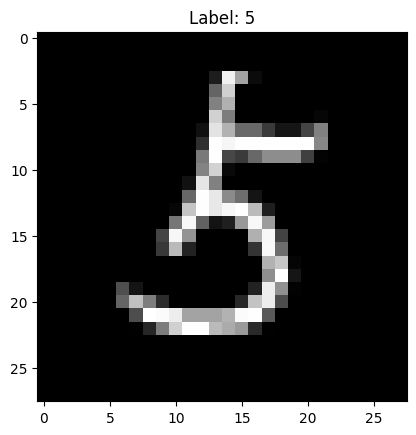

In [31]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap='grey')
plt.title(f"Label: {labels[0]}")
plt.show()

In [32]:
# Training data se ek batch lo
images, labels = next(iter(train_loader))

# Sirf pehli image lo
x = images[0].unsqueeze(0)  # shape: (1, 1, 28, 28)

# Conv layers se guzaro
x = model.pool(torch.relu(model.conv1(x)))
print(f"After conv1 + pool: {x.shape}")

x = model.pool(torch.relu(model.conv2(x)))
print(f"After conv2 + pool: {x.shape}")

print(f"Flatten size: {x.shape[1] * x.shape[2] * x.shape[3]}")

After conv1 + pool: torch.Size([1, 32, 13, 13])
After conv2 + pool: torch.Size([1, 64, 5, 5])
Flatten size: 1600


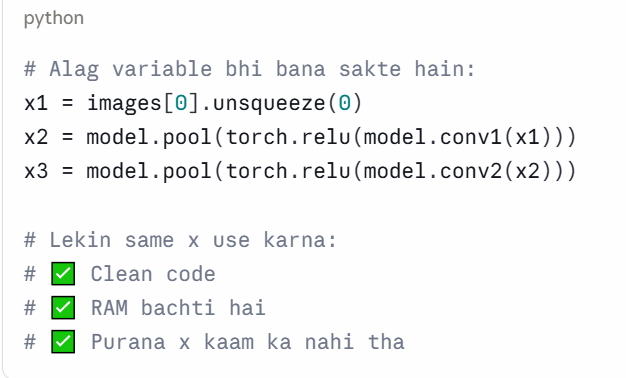

In [33]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Conv Layer 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        # Conv Layer 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        # Fully Connected
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)
        # Activation
        self.relu = nn.ReLU()

    def forward(self, x):
      
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5) # -1 automatically batch size calculate krta hai
        # 3D tensor ko 1D mein badlo
        # Conv output = (batch, 64, 5, 5) → 3D
        # FC layer ko = (batch, 1600)     → 2D chahiye! 
        x = self.relu(self.fc1(x)) # fuly connected layer ko 2 d chhaiyai hota hai isi liyai oper walai ko
   
        x = self.fc2(x)
        return x
    

model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


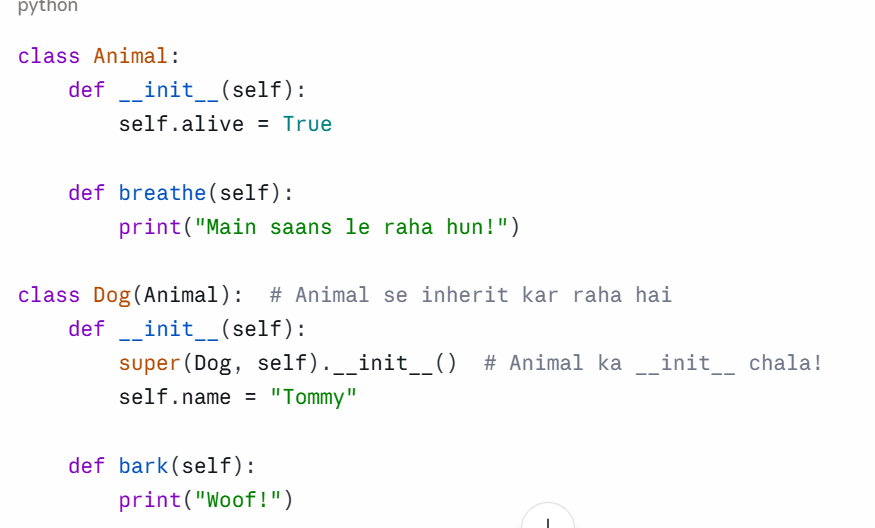

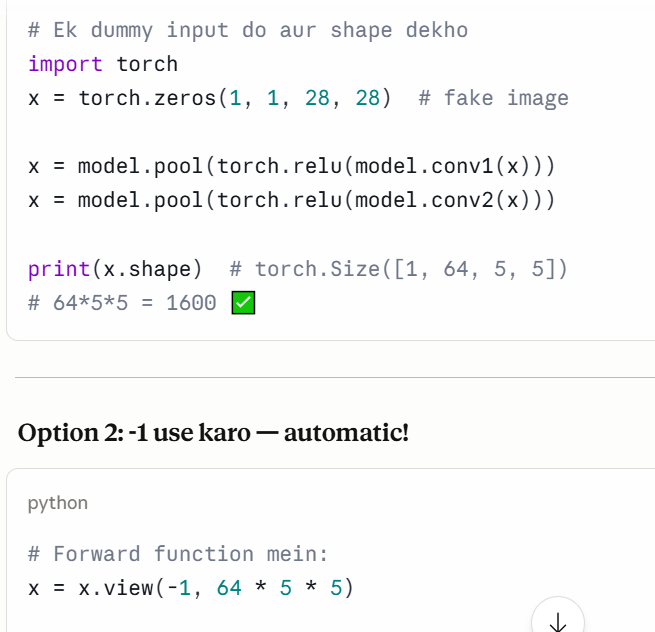
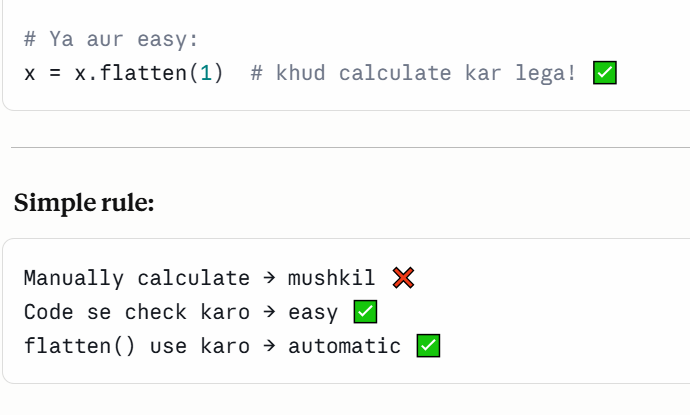

In [34]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Ready to train!")

Ready to train!


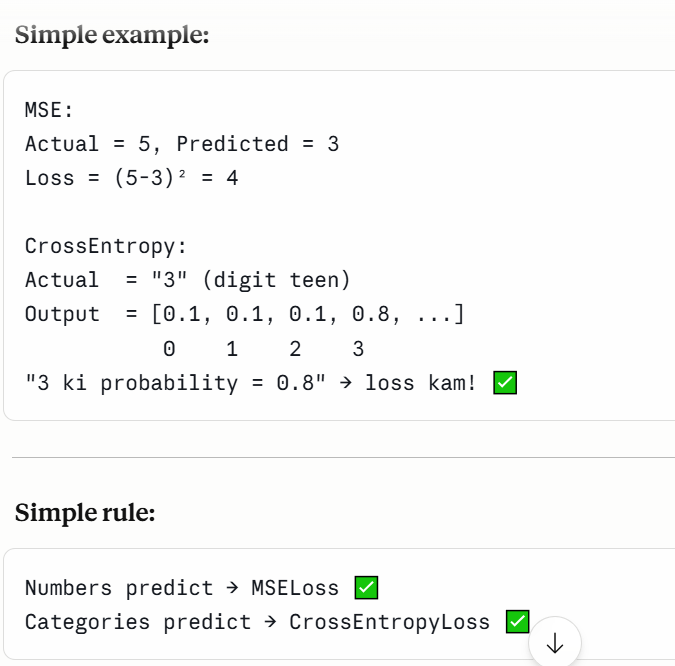
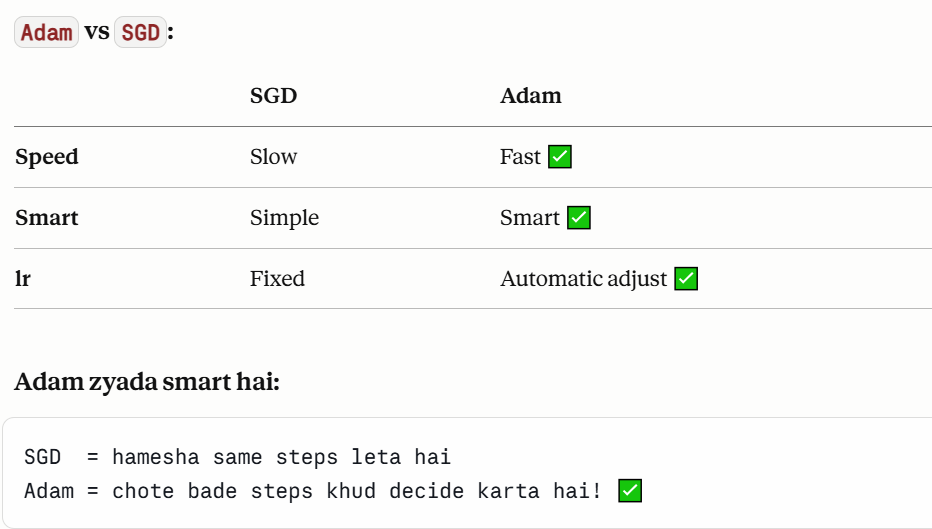

In [35]:
epochs = 20

for epoch in range(epochs):
    total_loss = 0
    
    for images, labels in train_loader:
        # Forward pass
        output = model(images)
        loss = loss_fn(output, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # Ek epoch mein 938 batches hain
        # Har batch ka alag loss hota hai

        # Batch 1 loss = 0.5
        # Batch 2 loss = 0.4
        # Batch 3 loss = 0.3
        # ...938 batches
    
    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

print("Training Complete!")

Epoch 1: Loss = 0.1515
Epoch 2: Loss = 0.0444
Epoch 3: Loss = 0.0304
Epoch 4: Loss = 0.0219
Epoch 5: Loss = 0.0176
Training Complete!


In [40]:
correct = 0
total = 0

with torch.no_grad(): #koi grad calculate nhi krna testing mai
    for images, labels in test_loader:  #test  loader sai betch uthaey ga
        output = model(images)  #forward pass hoga
        _, predicted = torch.max(output, 1) 
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.10%


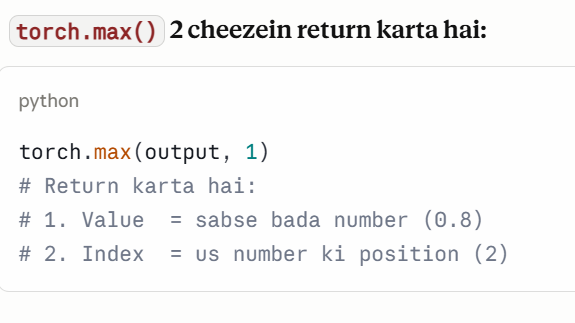
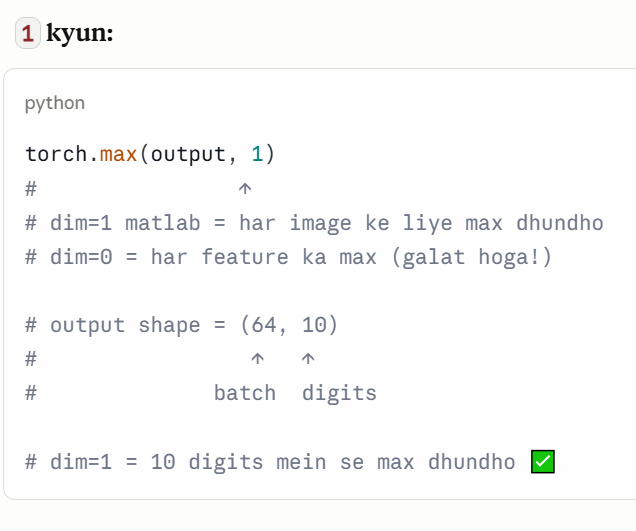

In [37]:
from PIL import Image
import torchvision.transforms as transforms
import torch

# Apni image load karo
img = Image.open(r"C:\Users\PMLS\Downloads\thrrrr.jpg").convert('L')  # Grayscale

# Transform
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Transform apply karo
img_tensor = transform(img).unsqueeze(0)

# Predict karo
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    print(f"Predicted Digit: {predicted.item()}")

Predicted Digit: 4


In [42]:
from PIL import Image, ImageOps
import torchvision.transforms as transforms
import torch

img = Image.open(r"C:\Users\PMLS\Downloads\WhatsApp Image 2026-04-28 at 11.42.50 AM.jpeg").convert('L')

# Image invert karo black hai to white kro white hai to back
img = ImageOps.invert(img)

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

img_tensor = transform(img).unsqueeze(0)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    print(f"Predicted Digit: {predicted.item()}")

Predicted Digit: 4


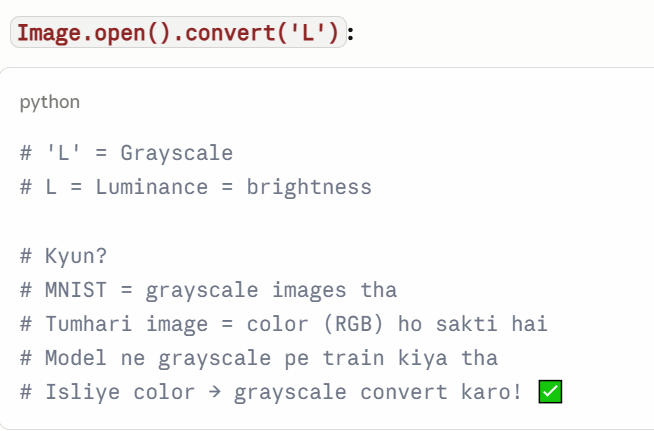
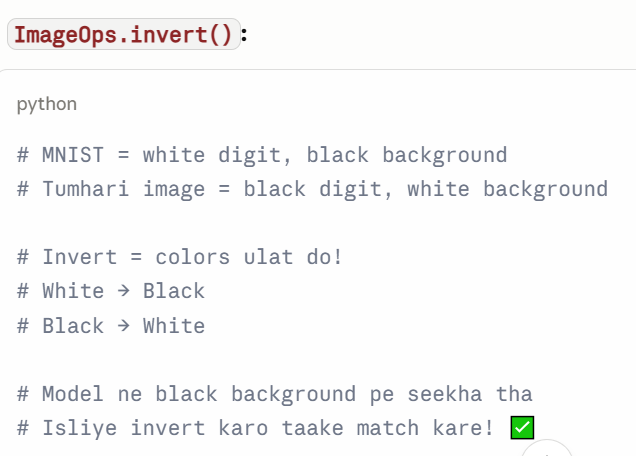
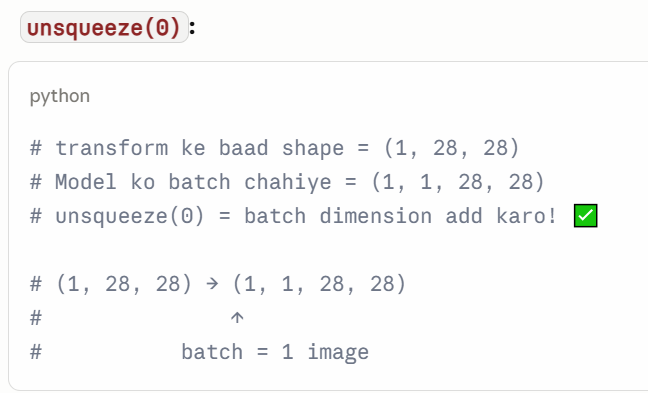

In [39]:
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved!")

Model saved!


# btach number kha hota hai
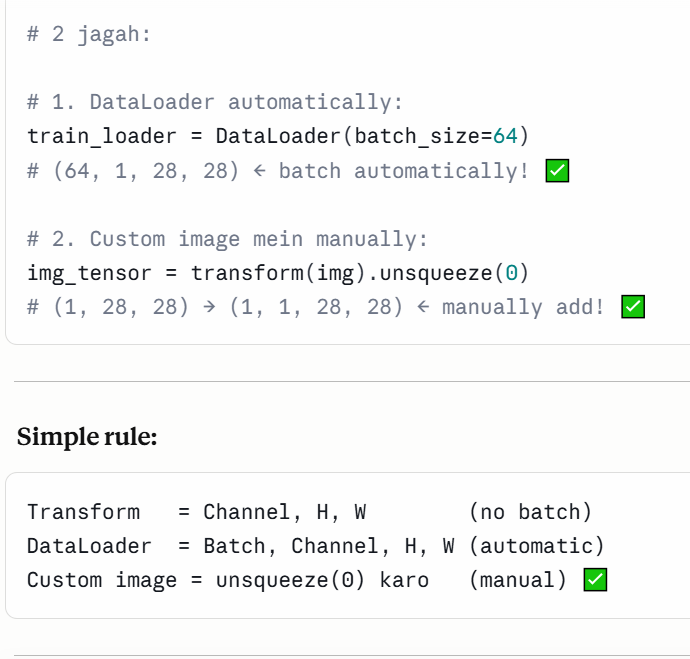
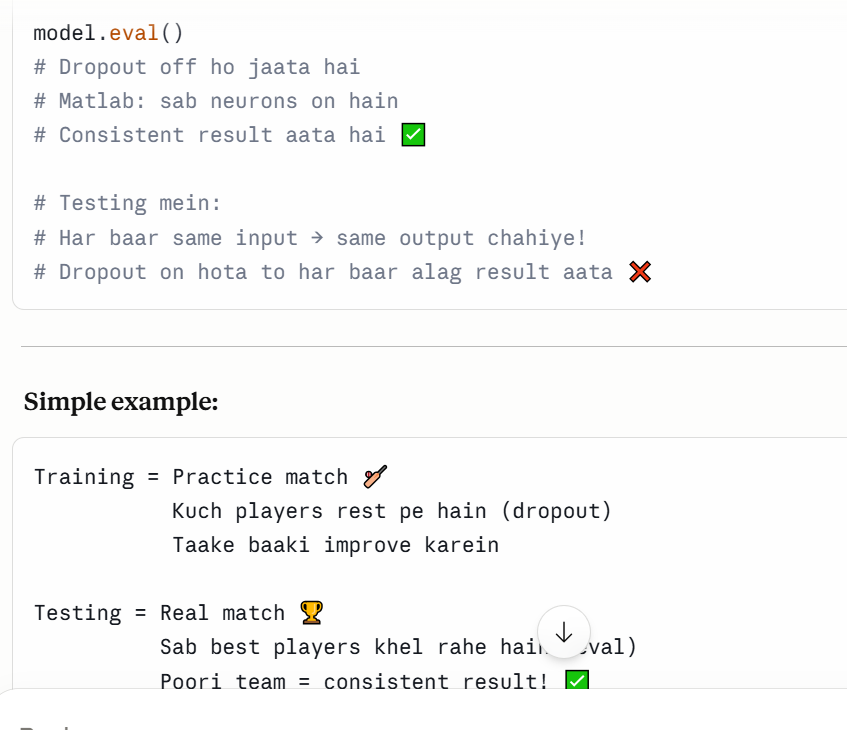